# 1. Calibración de cámaras
La calibración de cámara es esencial para cualquier aplicación de visión que requiera mediciones precisas o reconstrucción 3D. Permite:
- Corregir distorsiones de lente
- Establecer la relación entre coordenadas del mundo real y píxeles
- Obtener parámetros intrínsecos (matriz K, coeficientes de distorsión)

Este enlace contiene una guía para calibrar imágenes https://classroom.google.com/c/NzgwMDM2NDYwMzA5/m/ODEwMDkzMTg1MTgy/details

Para el reporte, deben incluir:
- Mostrar 4-6 imágenes con las esquinas detectadas dibujadas
- Código: cv2.drawChessboardCorners()
- Matriz de cámara K:
K = [fx 0 cx] 
       [0 fy cy] 
       [0 0    1]
- Coeficientes de distorsión: k1, k2, p1, p2, k3
- Error RMS de reproyección (debe ser < 0.5 píxeles para buena calibración)
- Mostrar al menos 3 imágenes originales vs. corregidas
- Evidenciar especialmente la corrección en las esquinas (donde la distorsión es mayor)
- ¿Qué tipo de distorsión predomina? (barril, cojín)
- ¿La longitud focal fx es similar a fy? ¿Por qué podría diferir?
- ¿El punto principal (cx, cy) está cerca del centro de la imagen?

In [19]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

Imágenes encontradas: 12
1. ../Imágenes Calibración\IMG_20251007_112001990.jpg
2. ../Imágenes Calibración\IMG_20251007_112022738.jpg
3. ../Imágenes Calibración\IMG_20251007_112030566.jpg
4. ../Imágenes Calibración\IMG_20251007_112038963.jpg
5. ../Imágenes Calibración\IMG_20251007_112125709.jpg
6. ../Imágenes Calibración\IMG_20251007_112137001.jpg
7. ../Imágenes Calibración\IMG_20251007_112145218.jpg
8. ../Imágenes Calibración\IMG_20251007_112201026.jpg
9. ../Imágenes Calibración\IMG_20251007_112252274.jpg
10. ../Imágenes Calibración\IMG_20251007_112300784.jpg
11. ../Imágenes Calibración\IMG_20251007_112310310.jpg
12. ../Imágenes Calibración\IMG_20251007_112318642.jpg


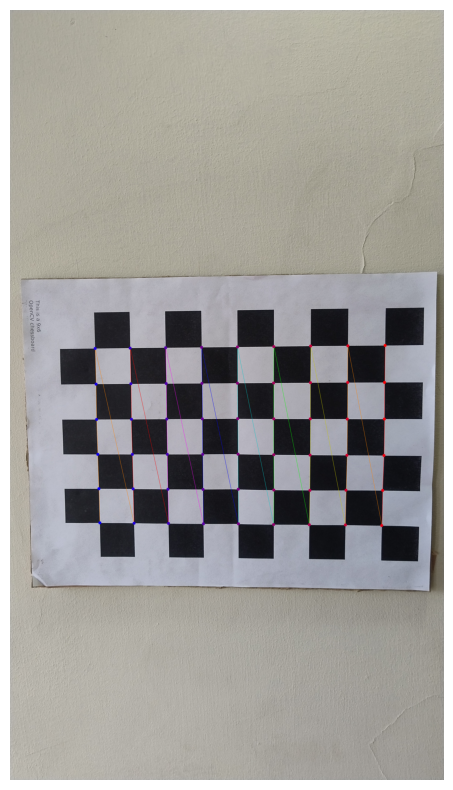

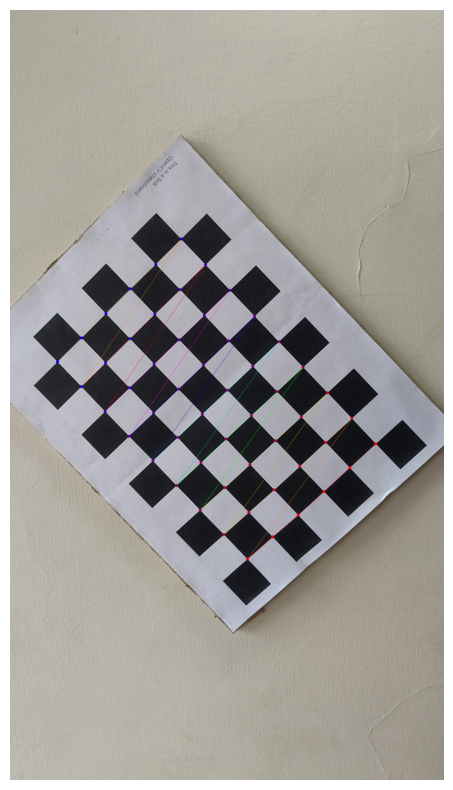

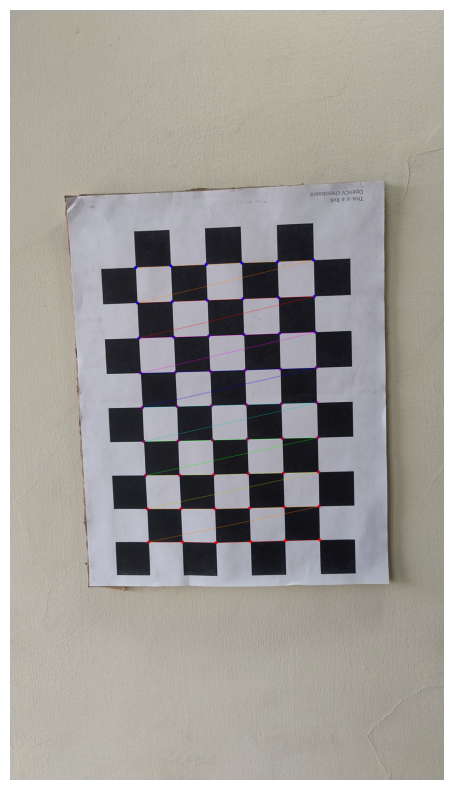

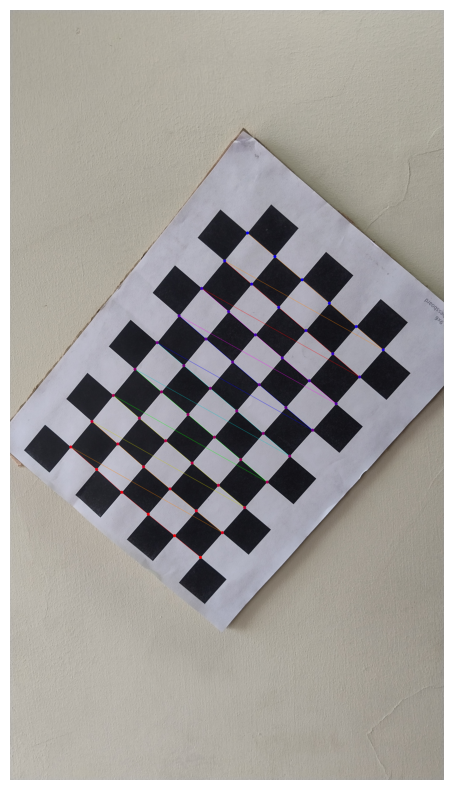

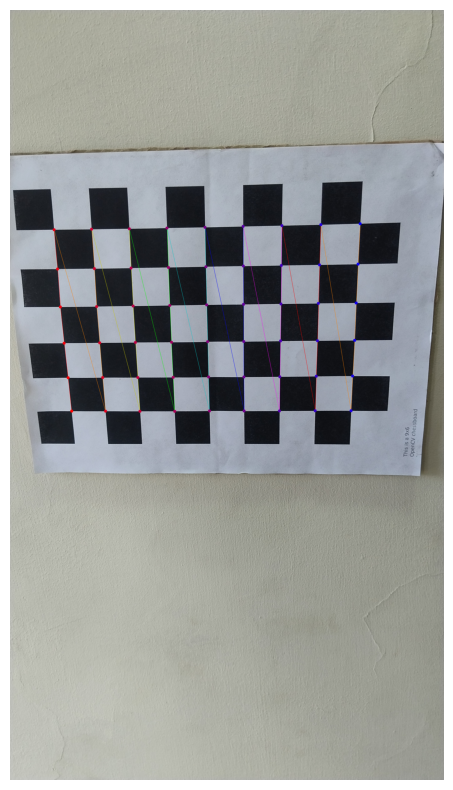

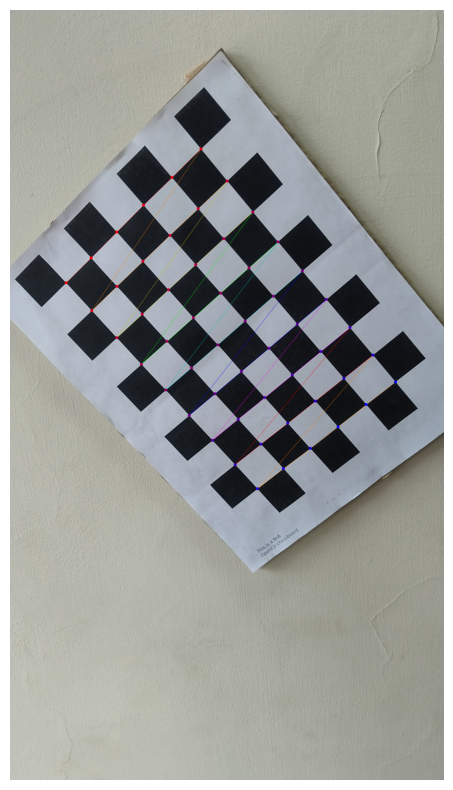

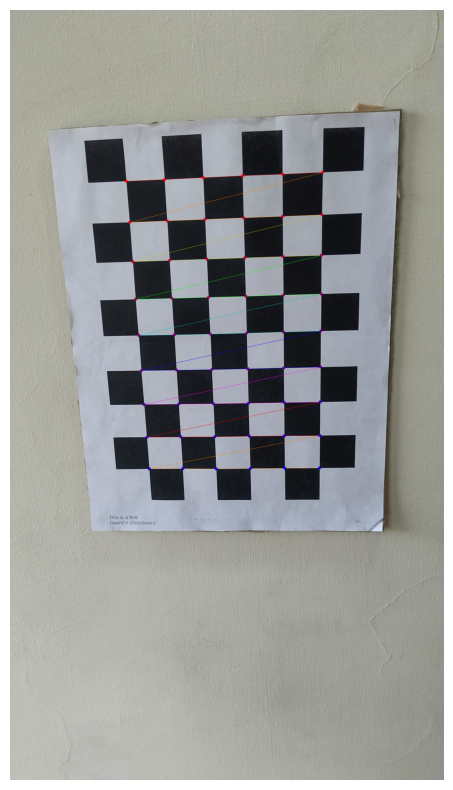

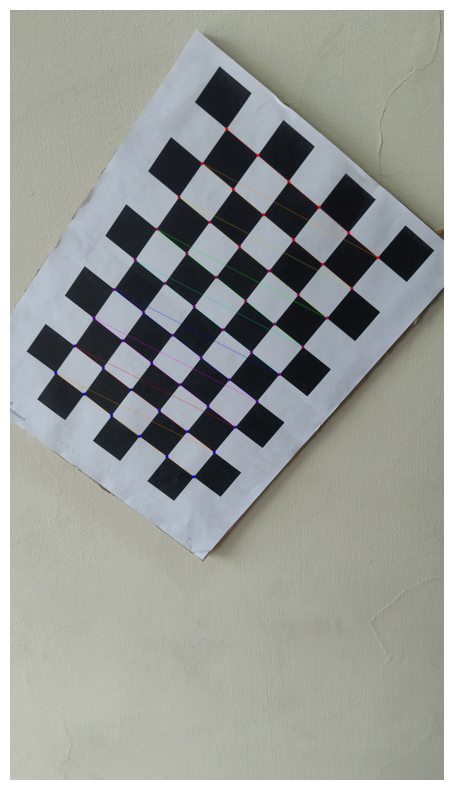

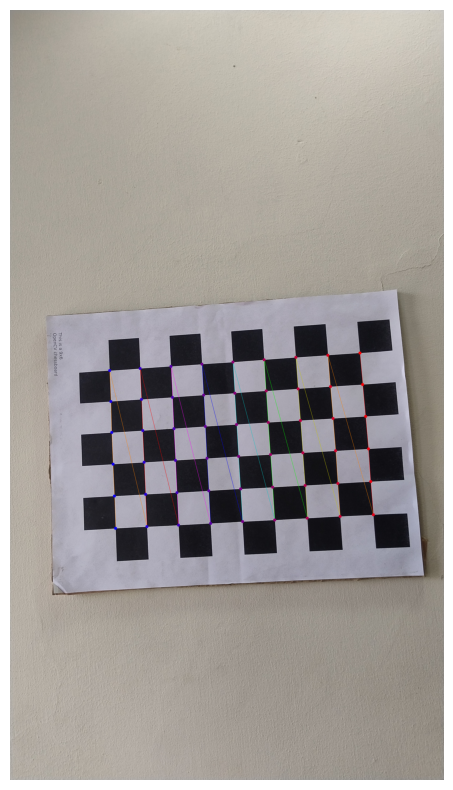

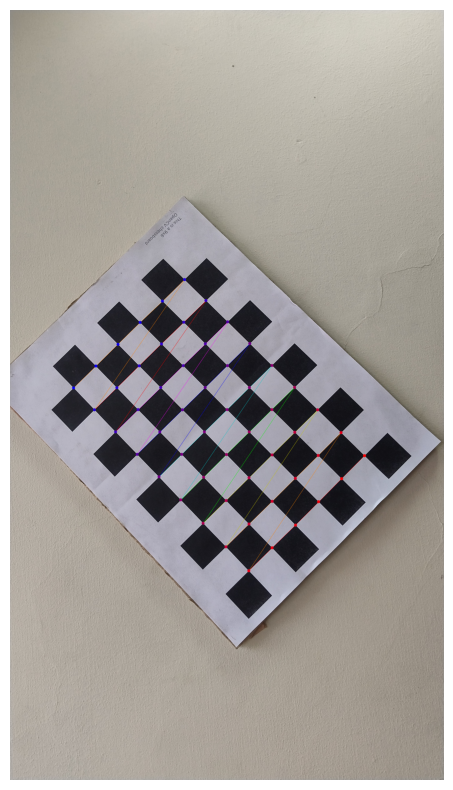

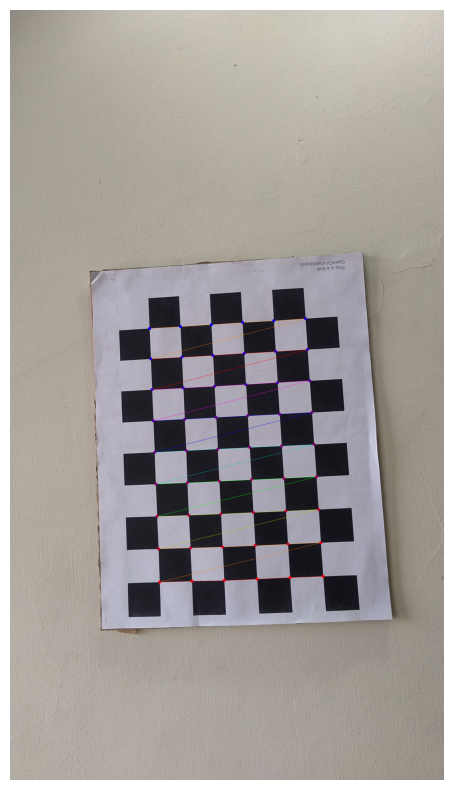

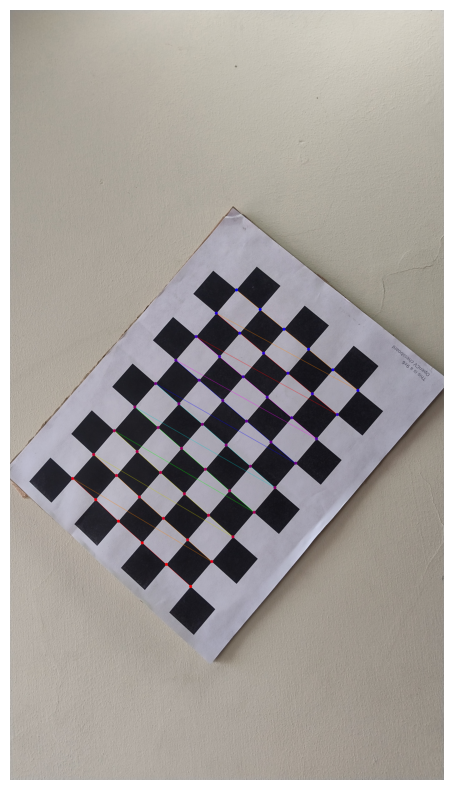

Camera matrix : 
 [[2.84822217e+03 0.00000000e+00 1.15093618e+03]
 [0.00000000e+00 2.84938203e+03 2.03476537e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 
 [[ 6.17606893e-02 -7.49744739e-01 -2.16294528e-03  1.48291907e-03
   2.47702561e+00]]
rvecs : 
 (array([[ 0.10797935],
       [-0.01410327],
       [ 1.56356421]]), array([[ 0.09841261],
       [-0.05943393],
       [ 2.37932971]]), array([[ 0.08662049],
       [-0.11130576],
       [ 3.10679633]]), array([[-0.03061348],
       [ 0.10922867],
       [-2.43335934]]), array([[ 0.17005181],
       [ 0.24159248],
       [-1.5708651 ]]), array([[ 0.23761961],
       [ 0.15483202],
       [-0.71395081]]), array([[ 0.27294525],
       [ 0.07236846],
       [-0.02627574]]), array([[ 0.27794618],
       [-0.01190704],
       [ 0.66898161]]), array([[-0.02994839],
       [ 0.13112903],
       [ 1.50535451]]), array([[0.01723841],
       [0.155607  ],
       [2.35560037]]), array([[0.0856621 ],
       [0.16464303],
       [3.08

In [20]:
# Dimensiones internas del tablero de ajedrez (número de esquinas por fila y columna)
CHECKERBOARD = (6, 9)

# Criterio de terminación para la refinación de esquinas subpíxel
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Listas para almacenar puntos 3D (mundo real) y puntos 2D (imagen) detectados en cada imagen
objpoints = []  # Puntos 3D en el espacio del tablero
imgpoints = []  # Puntos 2D detectados en la imagen

# Coordenadas 3D del tablero (z=0), generadas automáticamente según el tamaño del tablero
objp = np.zeros((1, CHECKERBOARD[0]*CHECKERBOARD[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

prev_img_shape = None  # Se usará para guardar el tamaño de la primera imagen válida

# Buscar todas las imágenes JPG en la carpeta indicada
images = glob.glob('../Imágenes Calibración/*.jpg')
print(f"Imágenes encontradas: {len(images)}")
for i, f in enumerate(images):
    print(f"{i+1}. {f}")

# Procesar cada imagen para detectar esquinas del tablero
for fname in images:
    # Leer la imagen (soporta rutas unicode en Windows)
    img = cv2.imread(fname)
    if img is None:
        try:
            data = np.fromfile(fname, dtype=np.uint8)
            img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        except Exception:
            img = None

    if img is None:
        print(f"Warning: no se pudo leer la imagen: {fname}. Se omite.")
        continue

    # Convertir a escala de grises para la detección de esquinas
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    

    # Guardar el tamaño de la imagen (solo la primera vez)
    if prev_img_shape is None:
        prev_img_shape = gray.shape[::-1]

    # Buscar esquinas del tablero de ajedrez
    ret, corners = cv2.findChessboardCorners(
        gray, CHECKERBOARD,
        cv2.CALIB_CB_ADAPTIVE_THRESH +
        cv2.CALIB_CB_FAST_CHECK +
        cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    if ret:
        # Si se detectan esquinas, guardar puntos 3D y 2D
        objpoints.append(objp)
        # Refinar la posición de las esquinas
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)
        # Dibujar las esquinas detectadas en la imagen
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
        for i, corner in enumerate(corners2):
            x, y = corner.ravel()
            color = (int(255*(i/len(corners2))), 0, int(255*(1 - i/len(corners2))))  # De rojo a azul
            cv2.circle(img, (int(x), int(y)), 8, color, -1)

    # Mostrar la imagen con las esquinas detectadas en el notebook
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# Verificar que se hayan detectado esquinas en al menos una imagen
if len(objpoints) == 0 or len(imgpoints) == 0:
    raise RuntimeError("No se detectaron esquinas en ninguna imagen. Revisa las rutas/formatos de las imágenes y asegúrate de que las imágenes contengan el tablero indicado.")


# Calibrar la cámara usando los puntos detectados
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, prev_img_shape, None, None)

# Mostrar resultados de calibración
print("Camera matrix : \n", mtx)
print("dist : \n", dist)
print("rvecs : \n", rvecs)
print("tvecs : \n", tvecs)


In [21]:
# Cálculo del error RMS (Root Mean Square) de reproyección
# Este error mide la precisión de la calibración de la cámara
mean_error = 0
total_points = 0

for i in range(len(objpoints)):
    # Proyecta puntos 3D a 2D usando parámetros de calibración
    imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    
    # Calcula error euclidiano entre puntos detectados y proyectados
    error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
    
    mean_error += error
    total_points += len(imgpoints2)

# Calcula error RMS promedio
final_rms_error = mean_error / len(objpoints)

print(f"Error RMS de Reproyección (promedio por imagen): {final_rms_error} píxeles")

Error RMS de Reproyección (promedio por imagen): 0.20846876134339562 píxeles


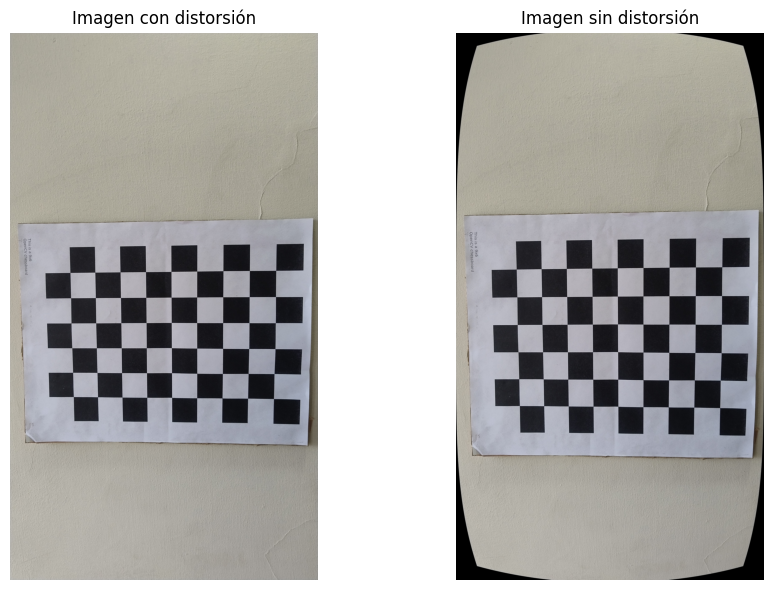

In [24]:
# Verificar/cargar variables necesarias
if 'images' not in globals():
    images = glob.glob('../Imágenes Calibración/*.jpg')

if len(images) == 0:
    raise RuntimeError("No se encontraron imágenes para procesar.")

# Cargar primera imagen con manejo de errores para rutas unicode
distorted_img_filename = images[0]
distorted_image = cv2.imread(distorted_img_filename)
if distorted_image is None:
    try:
        data = np.fromfile(distorted_img_filename, dtype=np.uint8)
        distorted_image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    except Exception:
        distorted_image = None

if distorted_image is None:
    raise RuntimeError(f"No se pudo leer la imagen: {distorted_img_filename}")

# Obtener dimensiones de la imagen
h, w = distorted_image.shape[:2]

# Usar calibración existente o calcularla si no está disponible
if 'mtx' not in globals() or 'dist' not in globals():
    if len(objpoints) == 0 or len(imgpoints) == 0:
        raise RuntimeError("Faltan parámetros de calibración.")
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (w, h), None, None)

# Refinar matriz de cámara para preservar todos los píxeles (alpha=1)
optimal_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))

# Corregir distorsión de la imagen
undistorted_image = cv2.undistort(distorted_image, mtx, dist, None, optimal_camera_matrix)

# Convertir imágenes para visualización con Matplotlib
distorted_rgb = cv2.cvtColor(distorted_image, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted_image, cv2.COLOR_BGR2RGB)

# Mostrar comparación de imágenes
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(distorted_rgb)
plt.title("Imagen con distorsión")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_rgb)
plt.title("Imagen sin distorsión")
plt.axis("off")

plt.tight_layout()
plt.show()

# Liberar recursos (no necesario en Jupyter pero buena práctica)
cv2.destroyAllWindows()

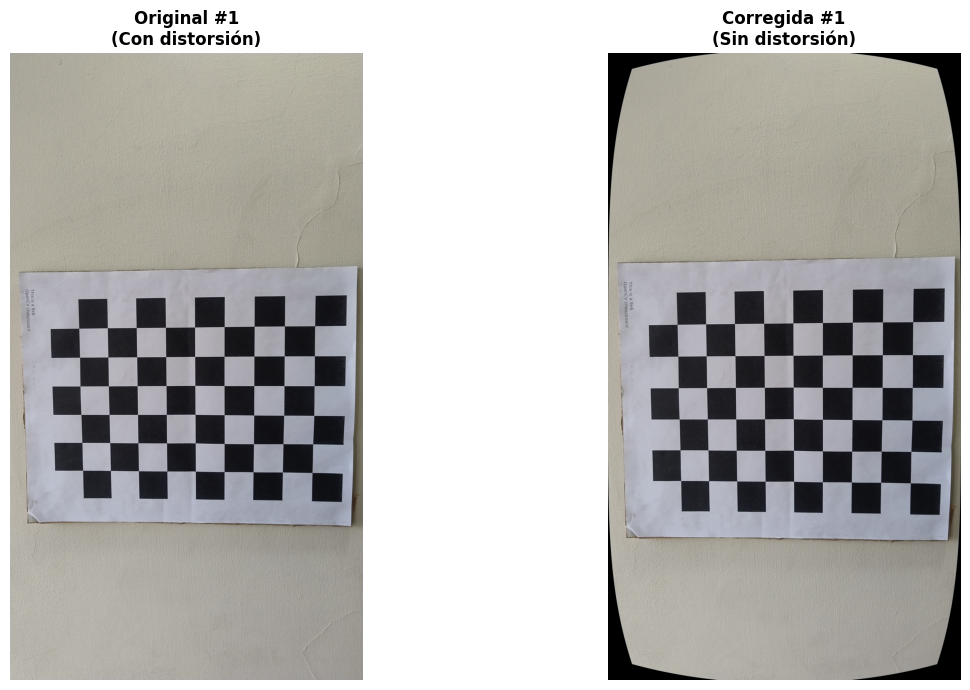

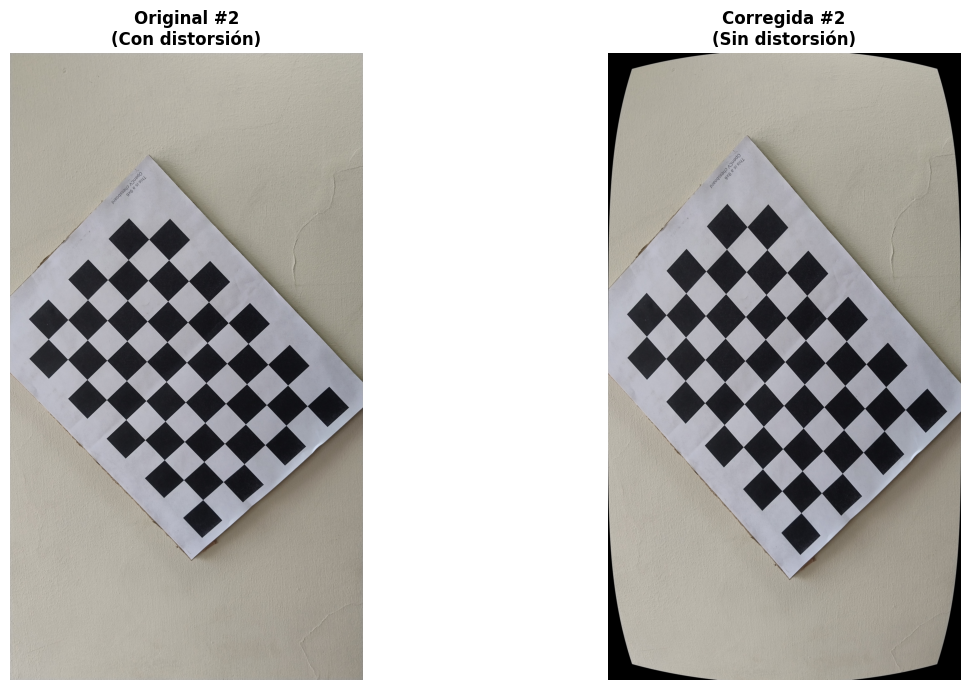

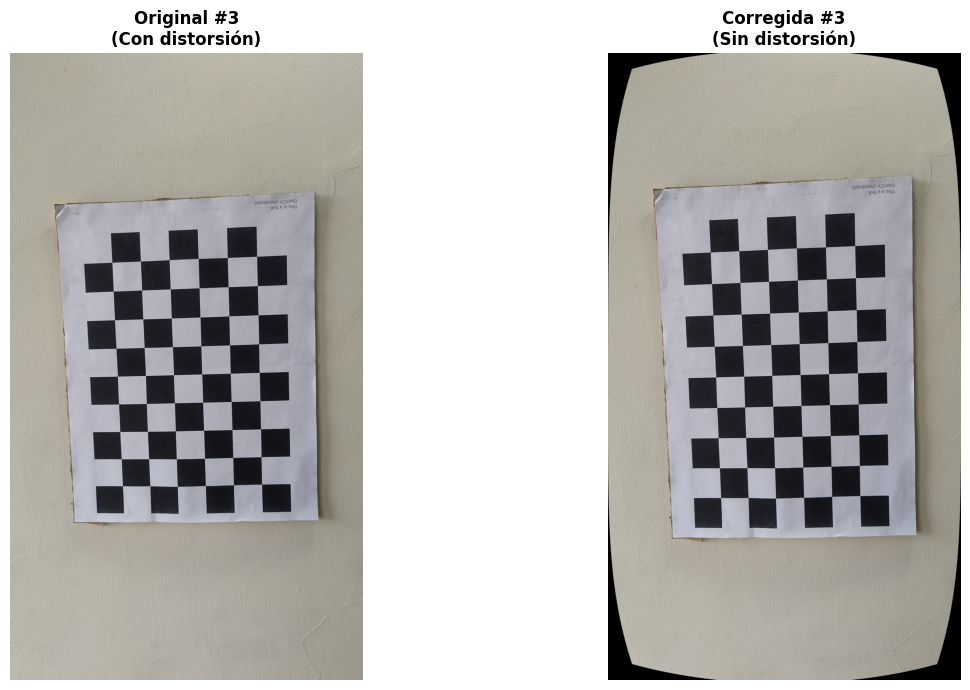


✓ Visualización completada.
💡 Observa las líneas rectas y bordes para apreciar la corrección.


In [26]:
# PREREQUISITO: mtx, dist, w, h, e 'images' deben estar definidos previamente

# VISUALIZACIÓN: Comparación de imágenes originales vs. corregidas

# Número de imágenes a procesar para la comparación
NUM_IMAGENES_COMPARAR = 3

for i in range(NUM_IMAGENES_COMPARAR):
    # Validar que hay suficientes imágenes disponibles
    if i >= len(images):
        print(f"⚠ Advertencia: Solo hay {len(images)} imagen(es) disponible(s).")
        break

    distorted_img_filename = images[i]


    # 1. CARGA ROBUSTA DE IMAGEN (soporta rutas con caracteres Unicode)
    img_original = cv2.imread(distorted_img_filename)
    
    # Método alternativo si falla la carga estándar (común en Windows)
    if img_original is None:
        try:
            data = np.fromfile(distorted_img_filename, dtype=np.uint8)
            img_original = cv2.imdecode(data, cv2.IMREAD_COLOR)
        except Exception as e:
            print(f"✗ Error al cargar '{distorted_img_filename}': {e}")
            continue

    if img_original is None:
        print(f"✗ No se pudo leer: {distorted_img_filename}. Saltando...")
        continue

    # 2. PREPARACIÓN DE LA IMAGEN ORIGINAL
    h_i, w_i = img_original.shape[:2]  # Dimensiones de la imagen actual
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)  # BGR → RGB para Matplotlib

    # 3. CORRECCIÓN DE DISTORSIÓN
    # Alpha=1: Mantiene todos los píxeles (sin recorte, puede tener bordes negros)
    optimal_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
        mtx, dist, (w_i, h_i), alpha=1, newImgSize=(w_i, h_i)
    )
    
    # Aplicar corrección usando los parámetros de calibración
    img_corregida = cv2.undistort(img_original, mtx, dist, None, optimal_camera_matrix)
    img_corregida_rgb = cv2.cvtColor(img_corregida, cv2.COLOR_BGR2RGB)

    # 4. VISUALIZACIÓN COMPARATIVA
    plt.figure(figsize=(14, 7))

    # Imagen original con distorsión
    plt.subplot(1, 2, 1)
    plt.imshow(img_original_rgb)
    plt.title(f"Original #{i+1}\n(Con distorsión)", fontsize=12, fontweight='bold')
    plt.axis("off")

    # Imagen corregida sin distorsión
    plt.subplot(1, 2, 2)
    plt.imshow(img_corregida_rgb)
    plt.title(f"Corregida #{i+1}\n(Sin distorsión)", fontsize=12, fontweight='bold')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\n✓ Visualización completada.")
print("💡 Observa las líneas rectas y bordes para apreciar la corrección.")